# **Child Well-being - Data Exploration**<br/>
**University: University of Milano-Bicocca**<br/>
**Master's Degree: Data Science (A.Y. 2025/2026)**<br/>
**Course: Data Science Lab**<br/>

In [1]:
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pl.read_parquet('../data/010_child_well_being.parquet')

### Missing analysis

In [4]:
# 1. Identify columns to aggregate
aggregation_columns = [col for col in df.columns if col not in ["REF_AREA", "TIME_PERIOD"]]
n_columns = len(aggregation_columns)

# 2. Compute nulls per row before grouping
df_with_nulls = df.with_columns(
    pl.sum_horizontal(pl.col(aggregation_columns).is_null()).alias("tot_null_rows")
)

# 3. Group by and sum the total nulls for each group
report_null = (
    df_with_nulls.group_by(["TIME_PERIOD", "REF_AREA"])
    .agg(
        (pl.col("tot_null_rows").sum() / (pl.len() * n_columns) * 100).alias("pct_null")
    )
    .sort(["TIME_PERIOD", "pct_null"], descending=[False, True])
)

# 4. Display the report
for year, group in report_null.group_by("TIME_PERIOD"):
    print(f"\n{year}:")
    for row in group.iter_rows(named=True):
        print(f"  {row['REF_AREA'].lower()} {row['pct_null']:.1f}% null")



(2009,):
  hrv 87.5% null
  rou 81.2% null
  bgr 81.2% null
  tur 68.8% null
  est 50.0% null
  deu 50.0% null
  aut 50.0% null
  ltu 46.9% null
  nld 46.9% null
  dnk 46.9% null
  swe 46.9% null
  lux 43.8% null
  che 43.8% null
  fra 43.8% null
  nor 40.6% null
  esp 40.6% null
  grc 40.6% null
  svn 40.6% null
  fin 40.6% null
  hun 40.6% null
  gbr 40.6% null
  lva 40.6% null
  irl 37.5% null
  isl 37.5% null
  bel 37.5% null
  cze 37.5% null
  prt 37.5% null
  pol 34.4% null
  svk 34.4% null
  ita 34.4% null

(2012,):
  hrv 81.2% null
  bgr 71.9% null
  rou 71.9% null
  tur 53.1% null
  swe 37.5% null
  est 34.4% null
  che 34.4% null
  lva 34.4% null
  ltu 34.4% null
  irl 34.4% null
  nor 31.2% null
  dnk 31.2% null
  svn 31.2% null
  isl 31.2% null
  nld 31.2% null
  fin 28.1% null
  aut 28.1% null
  prt 28.1% null
  grc 28.1% null
  lux 28.1% null
  deu 25.0% null
  bel 25.0% null
  gbr 25.0% null
  cze 25.0% null
  esp 25.0% null
  ita 25.0% null
  hun 25.0% null
  pol 21.9%

In [5]:
# Selecting countries that have more than 50% of missing values
critic_countries = report_null.filter(pl.col("pct_null") > 50).select("REF_AREA").unique().to_series().to_list()

print("Nations with more than 50% null values (in at least one period):", critic_countries)

Nations with more than 50% null values (in at least one period): ['BGR', 'HRV', 'ROU', 'TUR']


In [6]:
# Delete rows with critical countries
df_filtered = df.filter(~pl.col("REF_AREA").is_in(critic_countries))

print(f"Number of rows removed: {df.height - df_filtered.height}")
print(f"Dimensions of the original DataFrame: {df.shape}")
print(f"Dimensions of the filtered DataFrame: {df_filtered.shape}")

Number of rows removed: 16
Dimensions of the original DataFrame: (120, 34)
Dimensions of the filtered DataFrame: (104, 34)


In [8]:
# Missing count for each column and calculation of the percentage
print('Percentage of missing values before the elimination of critical countries:')
missing = (
    df.null_count()                         
           .transpose(include_header=True,
                      header_name="column",
                      column_names=["n_missing"])
           .with_columns(
               (pl.col("n_missing") / df.height * 100).round(2).alias("pct_missing")
           )
           .sort("pct_missing", descending=True)
)
print(missing)

Percentage of missing values before the elimination of critical countries:
shape: (34, 3)
┌─────────────┬───────────┬─────────────┐
│ column      ┆ n_missing ┆ pct_missing │
│ ---         ┆ ---       ┆ ---         │
│ str         ┆ u32       ┆ f64         │
╞═════════════╪═══════════╪═════════════╡
│ C4_6        ┆ 73        ┆ 60.83       │
│ A4_6        ┆ 68        ┆ 56.67       │
│ B4_3        ┆ 67        ┆ 55.83       │
│ C4_3        ┆ 66        ┆ 55.0        │
│ B2_4        ┆ 63        ┆ 52.5        │
│ …           ┆ …         ┆ …           │
│ A3_3        ┆ 2         ┆ 1.67        │
│ C1_3        ┆ 2         ┆ 1.67        │
│ A1_4        ┆ 1         ┆ 0.83        │
│ REF_AREA    ┆ 0         ┆ 0.0         │
│ TIME_PERIOD ┆ 0         ┆ 0.0         │
└─────────────┴───────────┴─────────────┘


In [9]:
print('Percentage of missing values after the elimination of critical countries:')
missing = (
    df_filtered.null_count()                         
           .transpose(include_header=True,
                      header_name="column",
                      column_names=["n_missing"])
           .with_columns(
               (pl.col("n_missing") / df_filtered.height * 100).round(2).alias("pct_missing")
           )
           .sort("pct_missing", descending=True)
)
print(missing)

Percentage of missing values after the elimination of critical countries:
shape: (34, 3)
┌────────┬───────────┬─────────────┐
│ column ┆ n_missing ┆ pct_missing │
│ ---    ┆ ---       ┆ ---         │
│ str    ┆ u32       ┆ f64         │
╞════════╪═══════════╪═════════════╡
│ A4_6   ┆ 59        ┆ 56.73       │
│ C4_6   ┆ 59        ┆ 56.73       │
│ B4_3   ┆ 56        ┆ 53.85       │
│ B2_4   ┆ 54        ┆ 51.92       │
│ B1_5   ┆ 53        ┆ 50.96       │
│ …      ┆ …         ┆ …           │
│ C2_3   ┆ 0         ┆ 0.0         │
│ C3_1   ┆ 0         ┆ 0.0         │
│ C3_2   ┆ 0         ┆ 0.0         │
│ C3_3   ┆ 0         ┆ 0.0         │
│ C5_1   ┆ 0         ┆ 0.0         │
└────────┴───────────┴─────────────┘


In [10]:
# Compute the null percentage for each year-variable combination 
indicators = [c for c in df_filtered.columns if c not in ("REF_AREA", "TIME_PERIOD")]

missing_per_year = (
    df_filtered
    .group_by("TIME_PERIOD")
    .agg([
        (pl.col(c).is_null().sum() / pl.len() * 100).round(1).alias(c)
        for c in indicators
    ])
    .sort("TIME_PERIOD")
)
print("Percentage of missing values per indicator and year:")
missing_per_year

Percentage of missing values per indicator and year:


TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2009,100.0,3.8,0.0,3.8,61.5,3.8,100.0,30.8,100.0,57.7,100.0,100.0,100.0,100.0,7.7,19.2,0.0,15.4,15.4,0.0,0.0,0.0,0.0,0.0,0.0,3.8,100.0,100.0,23.1,88.5,100.0,0.0
2012,3.8,0.0,0.0,0.0,100.0,7.7,100.0,15.4,100.0,46.2,100.0,100.0,3.8,100.0,7.7,3.8,0.0,11.5,11.5,0.0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,65.4,3.8,38.5,96.2,0.0
2015,3.8,0.0,0.0,0.0,3.8,3.8,15.4,3.8,0.0,53.8,3.8,0.0,3.8,3.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.8,0.0,23.1,3.8,15.4,19.2,0.0
2018,3.8,0.0,0.0,3.8,11.5,0.0,11.5,3.8,3.8,3.8,3.8,0.0,3.8,11.5,92.3,3.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,92.3,0.0,11.5,0.0,11.5,11.5,0.0


In [11]:
report = (
    df_filtered.group_by("TIME_PERIOD")
    .agg(
        pl.len().alias("num_countries"),
        ((pl.sum_horizontal(pl.col(indicators).is_null()).sum() / (pl.len() * len(indicators))) * 100)
        .round(1)
        .alias("avg_missing_pct")
    )
    .sort("TIME_PERIOD")
)

print(report)

shape: (4, 3)
┌─────────────┬───────────────┬─────────────────┐
│ TIME_PERIOD ┆ num_countries ┆ avg_missing_pct │
│ ---         ┆ ---           ┆ ---             │
│ i64         ┆ u32           ┆ f64             │
╞═════════════╪═══════════════╪═════════════════╡
│ 2009        ┆ 26            ┆ 41.7            │
│ 2012        ┆ 26            ┆ 28.7            │
│ 2015        ┆ 26            ┆ 5.0             │
│ 2018        ┆ 26            ┆ 8.9             │
└─────────────┴───────────────┴─────────────────┘


In [12]:
# Drop rows having TIME_PERIOD equal to 2009 or 2012, as they have a very high percentage of missing values

df_out = df_filtered.filter(~pl.col("TIME_PERIOD").is_in([2009, 2012]))

print("Years left in the DataFrame:")
print(df_out["TIME_PERIOD"].unique().to_list())

print(f"\nNew shape: {df_out.shape}")

Years left in the DataFrame:
[2015, 2018]

New shape: (52, 34)


In [13]:
df_partitioned = df_out.partition_by("TIME_PERIOD", as_dict=True)
df_by_year = {key[0]: sub_df for key, sub_df in df_partitioned.items()}

### Correlation Analysis

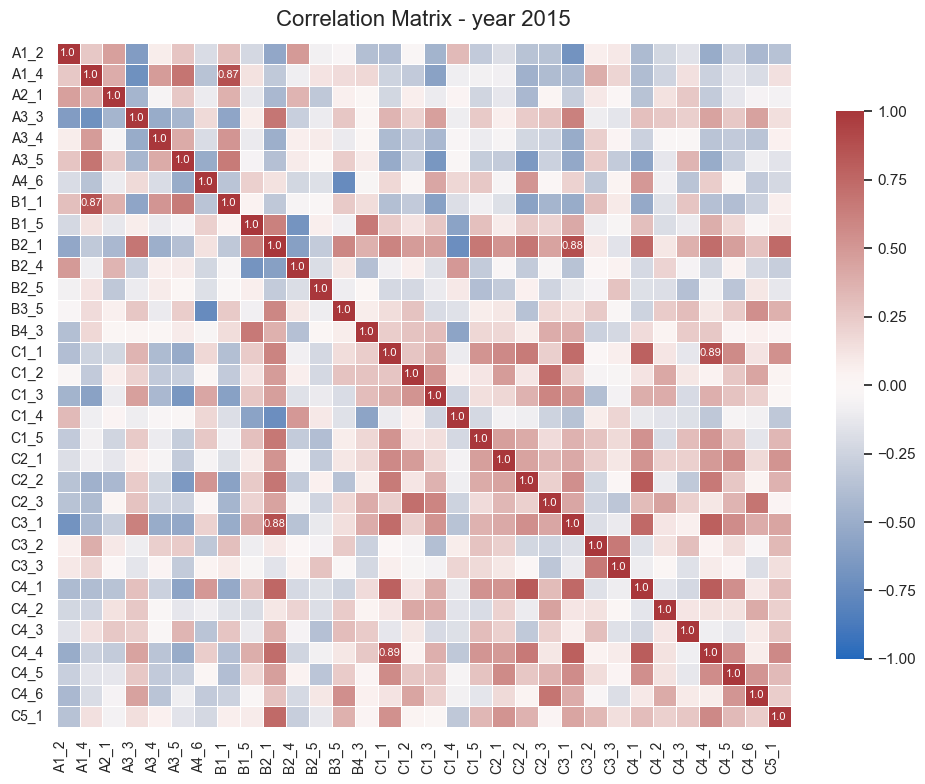

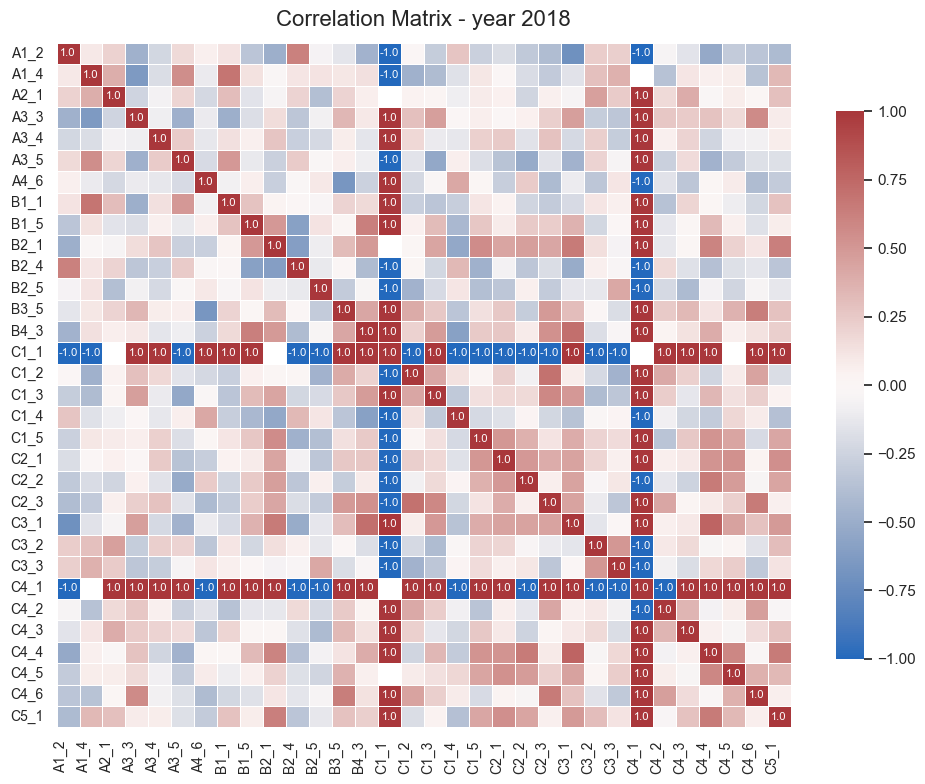

In [14]:
sns.set_theme(style="white")  

for a, sub in df_by_year.items():

    df = pd.DataFrame(sub).replace(to_replace="null", value=np.nan).iloc[:, 2:]
    col= sub.columns[2:]
    df.columns = col
    corr = df.corr()

    annot = corr.round(2).astype(str)
    annot = annot.where(corr.abs() > 0.85, "")

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        corr,
        cmap="vlag",         
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8}, 
        annot_kws={"size": 8}, 

    )
    ax.set_title(f"Correlation Matrix - year {a}", fontsize=16, pad=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()

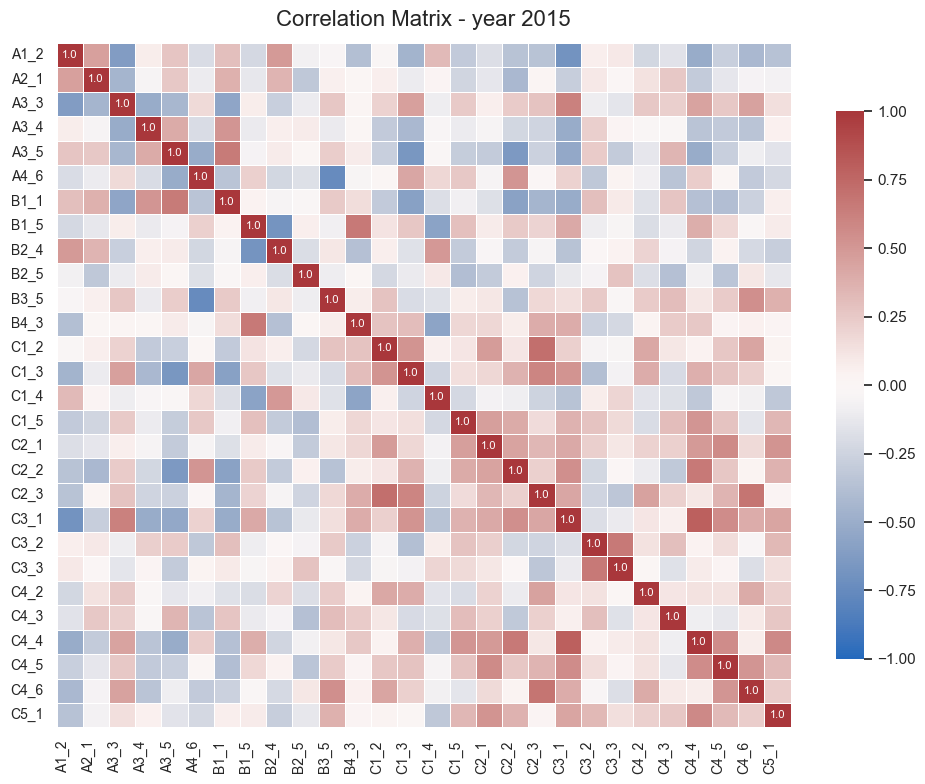

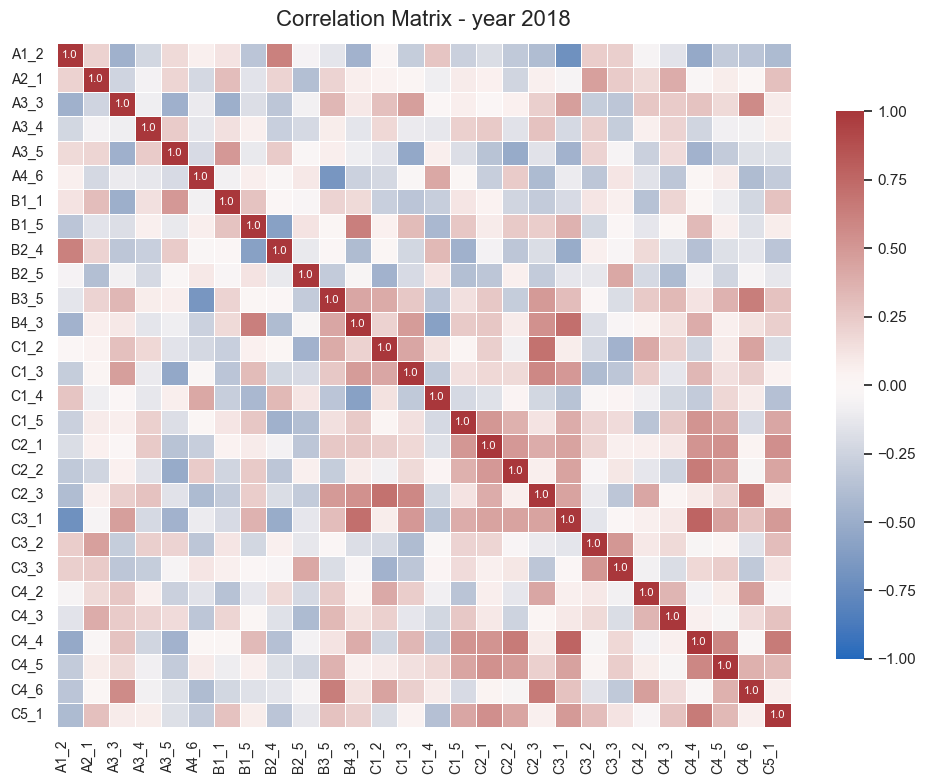

In [16]:
sns.set_theme(style="white")  

for a, sub in df_by_year.items():
    sub = sub.drop(["A1_4","B2_1","C4_1", "C1_1"])   # removing highly correlated columns
    df = pd.DataFrame(sub).replace(to_replace="null", value=np.nan).iloc[:, 2:]
    col= sub.columns[2:]
    df.columns = col
    corr = df.corr()

    annot = corr.round(2).astype(str)
    annot = annot.where(corr.abs() > 0.85, "")

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        corr,
        cmap="vlag",         
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8}, 
        annot_kws={"size": 8}, 

    )
    ax.set_title(f"Correlation Matrix - year {a}", fontsize=16, pad=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()

In [17]:
# Dropping the highly correlated columns from the original DataFrame
df_out = df_out.drop(["C4_1", "C1_1", ])

# Drop columns with more than 4 missing values
df_out = df_out.drop(['A1_4', 'B2_1', 'C4_3', ])

# Filter countries with more than 7 missing values
df_out = df_out.filter(
    ~pl.col('REF_AREA').is_in(['DNK', 'CHE', 'DEU', 'GRC', 'ISL', 'NLD', ])
)

# Filter countries with more than 5 missing values
df_out = df_out.filter(
    ~pl.col('REF_AREA').is_in(['NOR', 'BEL', 'FIN', 'IRL', ])
)

In [18]:
df_out.write_parquet('../data/020_child_well_being.parquet')